# Ando Consistent 5x5 step-edge example

An Ando consistent gradient operator. This notebook creates a simple black-to-white step edge, runs the filter, and plots the result.

## How this filter works

The Ando consistent gradient operators are derived from a consistency criterion. Ando decomposes the difference between the continuous gradient and the discrete operator into an intrinsic smoothing term and a self-inconsistency term, then minimizes only the self-inconsistency. This makes the estimated gradient direction exact for locally one-dimensional patterns, independent of orientation, spectral content, and sub-pixel shift. Each operator smooths along one axis and takes a central difference along the other. The 5x5 mask shipped here is the standard separable approximation of Ando's optimal operator.

### Paper reference

Use Ando's 2000 paper, *Consistent Gradient Operators*, IEEE Transactions on Pattern Analysis and Machine Intelligence 22(3), 252-265, DOI [10.1109/34.841757](https://doi.org/10.1109/34.841757).

## Setup

Import the small set of tools used in this notebook. The autoreload lines help Jupyter pick up local source edits without restarting the kernel.

In [1]:
# Imports and local reloads.
%load_ext autoreload
%autoreload 2

import time

import matplotlib.pyplot as plt
import torch

from agfb_filters import ExecutionPath, get_filter_definition, run_filter

## Filter settings

Choose the filter settings here. The `definition` describes the filter, and the `path` chooses the matching execution path.

In [2]:
# Change these settings to try the filter.
definition = get_filter_definition("ando_5")
path = ExecutionPath.SEPARABLE

## Test image

Create a test image. By default this is a synthetic step edge. The commented block lets you replace it with your own image file path.

(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

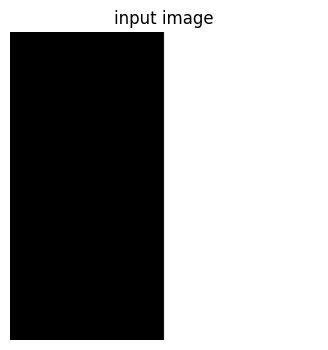

In [3]:
# Build the step-edge test image.
size = 1024
image = torch.zeros(1, size, size)
image[:, :, size // 2 :] = 1.0

# To use your own image instead, uncomment this block and set image_path.
# image_path = "path/to/image.png"
# image = torch.as_tensor(plt.imread(image_path), dtype=torch.float32)
# if image.ndim == 3:
#     image = image[..., :3].mean(dim=-1)
# image = image.unsqueeze(0)

plt.figure(figsize=(4, 4))
plt.imshow(image[0], cmap="gray", vmin=0, vmax=1)
plt.title("input image")
plt.axis("off")

## Filter weights

Visualize the fixed filter weights. `kernel_x` responds to left-to-right changes, and `kernel_y` responds to top-to-bottom changes.

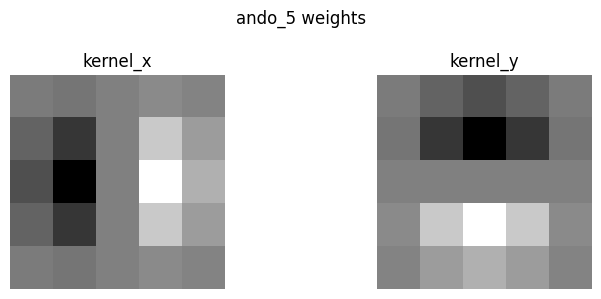

In [4]:
# Plot the filter weights.
kernel_x, kernel_y = definition.dense_kernels()
weight_limit = max(float(kernel_x.abs().max()), float(kernel_y.abs().max()))

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

for ax, kernel, title in zip(
    axes,
    (kernel_x, kernel_y),
    ("kernel_x", "kernel_y"),
    strict=False,
):
    ax.imshow(kernel, cmap="gray", vmin=-weight_limit, vmax=weight_limit)
    ax.set_title(title)
    ax.axis("off")

fig.suptitle(f"{definition.name} weights")
fig.tight_layout()

## Run the filter

Run the filter. The timer measures only the filter call, not the image setup or plotting.

In [5]:
# Time the filter call.
start = time.perf_counter()
gradient_x, gradient_y = run_filter(
    definition,
    image,
    path=path,
    boundary=definition.default_boundary,
)
elapsed = time.perf_counter() - start

print(f"{elapsed:.4f} seconds")

0.0077 seconds


## Gradient results

Plot the two gradient outputs with the same grayscale range. The input changes left-to-right, so the strongest response should usually be in `gradient_x`.

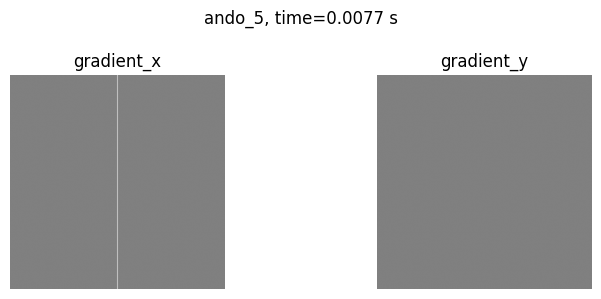

In [6]:
# Plot gradient_x and gradient_y.
limit = max(float(gradient_x.abs().max()), float(gradient_y.abs().max()))

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

axes[0].imshow(gradient_x[0], cmap="gray", vmin=-limit, vmax=limit)
axes[0].set_title("gradient_x")

axes[1].imshow(gradient_y[0], cmap="gray", vmin=-limit, vmax=limit)
axes[1].set_title("gradient_y")

for ax in axes:
    ax.axis("off")

fig.suptitle(f"{definition.name}, time={elapsed:.4f} s")
fig.tight_layout()